# Detección de Inyecciones SQL mediante técnicas de procesamiento de lenguaje natural y aprendizaje automático

## Introducción
Por Gonzalo Benito, Lic. en Sistemas de Información, Universidad Nacional de Luján, Argentina.

Este trabajo propone desarrollar un sistema de detección de ataques de Inyección SQL utilizando técnicas de procesamiento de lenguaje natural (NLP) y algoritmos de machine learning. Se empleó un dataset obtenido de Kaggle que contiene sentencias SQL etiquetadas como peligrosas o benignas. La metodología incluyó la transformación de las sentencias en vectores mediante una matriz TF-IDF sobre n-gramas de caracteres y palabras, seguida de la aplicación de algoritmos de clasificación como Support Vector Machines (SVM), Random Forest y Logistic Regression. El objetivo fue evaluar y comparar el desempeño de los modelos mediante métricas de precisión, recall y F1-score, y **demostrar si es posible la detección de ataques de inyección SQL mediante técnicas de Machine Learning**.

#### Detalles de lo que se incluirá en este trabajo
La metodología seguirá un enfoque basado en una matriz TF-IDF (matriz dispersa o *sparse*) sobre n-gramas de caracteres (y de palabras también). Con este método, cada sentencia se transforma en un vector o fila de la matriz; las columnas corresponden a n-gramas de longitud fija (por ejemplo, de 3 a 5 caracteres) o a combinaciones de palabras (más especificamente combinaciones de *tokens*, que llamaremos unigramas, bigramas o trigramas); y los valores de cada celda reflejan la frecuencia (o el peso TF-IDF, según la configuración utilizada) de cada n-grama en la sentencia. Se probarán diferentes configuraciones para los algoritmos usados durante la ingeniería de características (Feature Engineering), y se evaluarán las distintas matrices dispersas obtenidas con algoritmos de clasificación, como Support Vector Machines (SVM), Random Forest y Logistic Regression. El objetivo es evaluar y comparar el desempeño de las distintas configuraciones de los modelos, mediante las métricas de precisión más usadas, y demostrar si es posible la detección de ataques de inyección SQL mediante técnicas de Machine Learning.

## Descripción del dataset
El dataset utilizado es 'SQL Injection Dataset' de Syed Saqlain Hussain (Kaggle), con 30.920 filas y dos columnas principales: `Sentence` (consulta SQL o texto) y `Label` (0=benigna, 1=inyección).

| Atributo | Tipo | Descripción |
| -------- | ---- | ----------- |
| Sentence | texto | Consulta SQL completa o texto |
| Label | categórica | 0 = no inyección, 1 = inyección SQL |

De la variable Sentence se obtendrá el conjunto de features durante la fase de Feature Engineering, con clases como CountVectorizer, TfidfVectorizer, o Word2vec.

Link del dataset: https://www.kaggle.com/datasets/syedsaqlainhussain/sql-injection-dataset

## Instalación de librerías necesarias

In [ ]:
# Dependencias
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install numpy==1.26.4

### Importación del dataset y selección de features

In [2]:
import pandas as pd

data: pd.DataFrame = pd.read_csv("./data/SQLiV3.csv")  # El dataset debe tener columnas 'Sentence' y 'Label'
data

,Sentence,Label,Unnamed: 2,Unnamed: 3
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN
1,create user name identified by pass123 tempora...,NaN,1,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN
...,...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,NaN,NaN
30915,DELETE FROM tomorrow,0,NaN,NaN
30916,SELECT wide ( s ) FROM west,0,NaN,NaN
30917,SELECT * FROM ( SELECT slide FROM breath ),0,NaN,NaN


In [3]:
data = data[['Sentence', 'Label']].copy()  # Seleccionar solo las columnas necesarias
data['Sentence'] = data['Sentence'].astype(str)
data['length'] = data['Sentence'].apply(len)
data

,Sentence,Label,length
0,""" or pg_sleep ( __TIME__ ) --",1,33
1,create user name identified by pass123 tempora...,NaN,89
2,AND 1 = utl_inaddr.get_host_address ( ...,1,218
3,select * from users where id = '1' or @ @1 ...,1,90
4,"select * from users where id = 1 or 1#"" ( ...",1,85
...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,37
30915,DELETE FROM tomorrow,0,20
30916,SELECT wide ( s ) FROM west,0,28
30917,SELECT * FROM ( SELECT slide FROM breath ),0,44


## Preprocesamiento

### Limpieza de missing values y ruido

In [4]:
# Eliminar filas donde 'Sentence' es NaN
data = data.dropna(subset=['Sentence'])

# Me quedo solo con las clases 0 y 1 (por si hay algún otro valor en 'Label', como un string)
data = data[data['Label'].isin(['0', '1'])]

### Tokenización (para Word2vec, ver notebook correspondiente)

In [5]:
# import nltk
# from nltk.tokenize import word_tokenize
# nltk.download('punkt_tab')

# # Generación de tokens con NLTK (Natural Language Toolkit)
# def sentence_to_list(sentence):
#     return [sentence]

# data['Tokens'] = data['Sentence'].apply(word_tokenize)  # toma una cadena de texto (Sentence) y la divide en una lista de palabras o tokens
# # data['Tokens'] = data['Sentence'].apply(sentence_to_list)
# sentences = data['Tokens'].tolist()

# for i, sentence in enumerate(sentences[8:15], start=8):
#     print(f"Sentence {i}: {sentence}")
# print("Sentence n: ...")

## Análisis exploratorio de datos (EDA)
Exploramos la distribución de clases y longitud de sentencias.

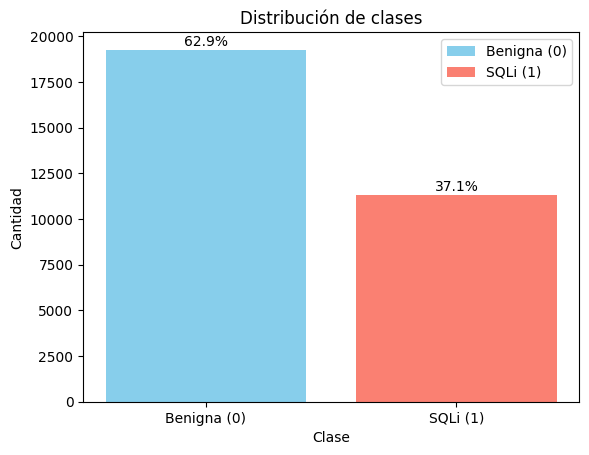

In [6]:
# Distribución de clases
import matplotlib.pyplot as plt

value_counts = data['Label'].value_counts()
percentage = (value_counts / value_counts.sum()) * 100
labels = ['Benigna (0)', 'SQLi (1)']

fig, axes = plt.subplots()
bars = axes.bar(labels, value_counts, color=['skyblue', 'salmon'], label=labels)

# Texto de porcentaje arriba de cada barra
for bar, pct in zip(bars, percentage):
    axes.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'{pct:.1f}%', ha='center', fontsize=10)

axes.set_title('Distribución de clases')
axes.set_xlabel('Clase')
axes.set_ylabel('Cantidad')
axes.legend()
plt.show()

Las clases están desbalanceadas. La clase mayoritaria es la 0 (sentencias benignas). Recurriremos a técnicas de balanceo para solucionar este problema.

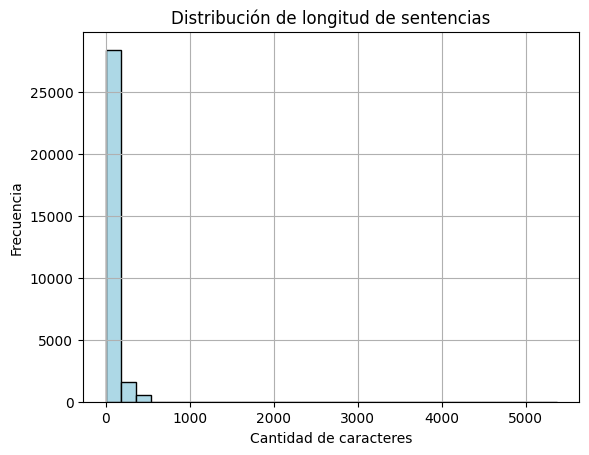

Cantidad de caracteres de la sentencia más larga: 5370


,Sentence,Label,length
19341,de]]> </email_address> <find_account_answer...,0,5370
19667,SELECT wp_posts.* FROM wp_posts LEFT JOIN wp_p...,0,559
19663,SELECT wp_posts.ID FROM wp_posts LEFT JOIN wp_...,0,529
9780,1'|| ( select 'rjis' from dual where 7696 =...,1,456
7270,"-6475"" ) ) ) or 4144 = ( selec...",1,455
...,...,...,...
628,!,1,1
19312,0,1,1
438,?,1,1
106,s,1,1


In [7]:
data['length'].hist(bins=30, color='lightblue', edgecolor='black')
plt.title('Distribución de longitud de sentencias')
plt.xlabel('Cantidad de caracteres')
plt.ylabel('Frecuencia')
plt.show()

print(f"Cantidad de caracteres de la sentencia más larga: {data['length'].max()}")
data_sort_by_length = data.sort_values(by='length', ascending=False)
data_sort_by_length

Vemos que la sentencia 19341 tiene una longitud atípica, 10 veces mayor que la segunda sentencia más larga. Esta es benigna. La eliminaremos del dataset por ser un outlier. Luego volvemos a mostrar el histograma de longitudes de sentencia.

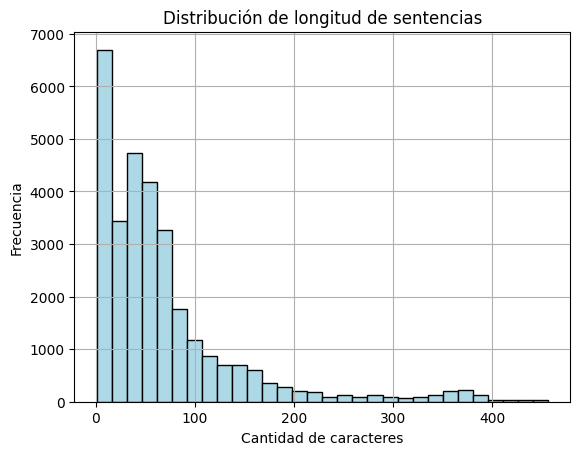

In [8]:
data = data[data['length'] <= 500]
data['length'].max()

data['length'].hist(bins=30, color='lightblue', edgecolor='black')
plt.title('Distribución de longitud de sentencias')
plt.xlabel('Cantidad de caracteres')
plt.ylabel('Frecuencia')
plt.show()

## Feature Engineering
Se exploran dos enfoques: TF-IDF y Word2Vec (este último en otro notebook). No se tendrán en cuenta los espacios en blanco de las sentencias.

In [10]:
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(3,3), analyzer='char_wb', min_df=3, lowercase=True, strip_accents='ascii', use_idf=False, stop_words='english', token_pattern=r'\b\w+\b') 
'''
usar use_idf=False para no penalizar por IDF
usar max_features=integer para limitar el número de características
analyzer='char_wb' hace que excluya los n-gramas con espacios al final o al principio

(*) Al usar analyzer='char_wb', tanto el parámetro token_pattern como stop_words no tienen efecto (se aplican solo cuando analyzer='word)
'''

matriz_rala_tfidf = tfidf.fit_transform(data['Sentence'])

# Mostrar las primeras 10 filas de la matriz TF-IDF
matriz_rala_tfidf_df = pd.DataFrame(matriz_rala_tfidf.toarray(), columns=tfidf.get_feature_names_out())
# Mostrar todos los features generados (nombres de columnas)
print(f"Cantidad total de features generados: {len(matriz_rala_tfidf_df.columns)}")
print(matriz_rala_tfidf_df.columns.tolist())

# print(tfidf.get_feature_names_out())
# Guardar en un archivo CSV las características TF-IDF
# X_tfidf_df.to_csv('TF-IDF-2.csv', index=False)

/home/guanart/tp-inteligencia-artificial/custom_env/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:539: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(
/home/guanart/tp-inteligencia-artificial/custom_env/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:547: UserWarning: The parameter 'token_pattern' will not be used since 'analyzer' != 'word'
  warnings.warn(


Cantidad total de features generados: 11601
[' !<', ' " ', ' ""', ' "$', ' "%', ' "&', ' ",', ' "-', ' ".', ' "0', ' "1', ' "2', ' "3', ' "5', ' ";', ' "?', ' "@', ' "]', ' "_', ' "a', ' "b', ' "c', ' "d', ' "e', ' "f', ' "g', ' "h', ' "i', ' "j', ' "k', ' "l', ' "m', ' "n', ' "o', ' "p', ' "q', ' "r', ' "s', ' "t', ' "u', ' "v', ' "w', ' "x', ' "y', ' "z', ' "{', ' # ', ' #"', ' #n', ' $ ', ' $+', ' $<', ' % ', ' %!', ' %$', ' %2', ' %e', ' %m', ' %y', " ' ", " '%", " ''", " ',", " '0", " '1", " '7", " '[", " '_", " 'a", " 'b", " 'c", " 'd", " 'e", " 'f", " 'g", " 'h", " 'i", " 'j", " 'k", " 'l", " 'm", " 'n", " 'o", " 'p", " 'q", " 'r", " 's", " 't", " 'u", " 'v", " 'w", " 'x", " 'y", " 'z", ' ( ', ' ) ', ' * ', ' *$', ' *1', ' *2', ' *3', ' *4', ' *5', ' *6', ' *7', ' *8', ' *9', ' + ', ' +$', " +'", ' +1', ' +\\', ' +c', ' , ', ' ,0', ' ,1', ' ,2', ' ,5', ' ,8', ' ,@', ' ,c', ' ,n', ' ,v', ' --', ' -1', ' -2', ' -3', ' -4', ' -5', ' -6', ' -7', ' -8', ' -9', ' -@', ' . ', ' ..', ' 

In [ ]:
# Instalación de imbalanced-learn para SMOTE
%pip install imbalanced-learn

### Balanceo de Clases

Como observamos anteriormente, el dataset presenta un desbalance significativo entre las clases. Para mejorar el rendimiento de los modelos y evitar sesgos hacia la clase mayoritaria, aplicaremos la técnica SMOTE (Synthetic Minority Oversampling Technique), que genera muestras sintéticas de la clase minoritaria creando ejemplos interpolados entre muestras existentes. Se optó por SMOTE por sobre RandomOverSampler, para evitar duplicar ejemplos existentes y fomentar la creación de nuevas instancias que reflejen mejor la distribución de la clase minoritaria.

In [12]:
from imblearn.over_sampling import SMOTE
import numpy as np

# Aplicar SMOTE a la matriz TF-IDF
smote = SMOTE(random_state=42, k_neighbors=5)
X_balanced, y_balanced = smote.fit_resample(matriz_rala_tfidf_df, data['Label'])

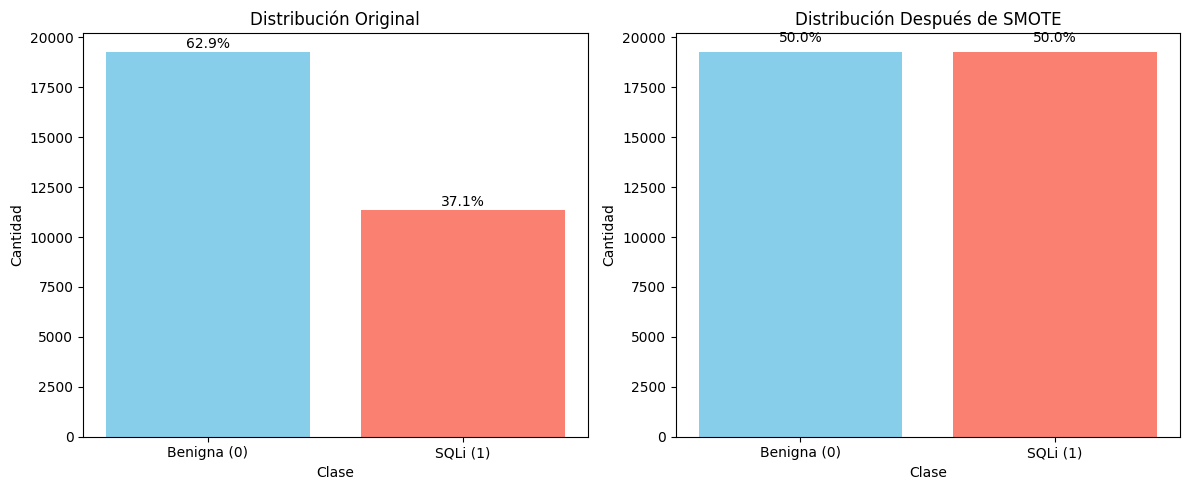

In [13]:
import matplotlib.pyplot as plt

# Visualización del balanceo de clases
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Distribución original
original_counts = data['Label'].value_counts()
original_percentage = (original_counts / original_counts.sum()) * 100
labels = ['Benigna (0)', 'SQLi (1)']

bars1 = ax1.bar(labels, original_counts, color=['skyblue', 'salmon'])
for bar, pct in zip(bars1, original_percentage):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'{pct:.1f}%', ha='center', fontsize=10)

ax1.set_title('Distribución Original')
ax1.set_xlabel('Clase')
ax1.set_ylabel('Cantidad')

# Distribución después de SMOTE
unique_balanced, counts_balanced = np.unique(y_balanced, return_counts=True)
balanced_percentage = (counts_balanced / counts_balanced.sum()) * 100

bars2 = ax2.bar(labels, counts_balanced, color=['skyblue', 'salmon'])
for bar, pct in zip(bars2, balanced_percentage):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f'{pct:.1f}%', ha='center', fontsize=10)

ax2.set_title('Distribución Después de SMOTE')
ax2.set_xlabel('Clase')
ax2.set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

### ¿Cómo genera SMOTE una instancia sintética en este contexto?

SMOTE no genera nuevas sentencias de texto, sino que crea nuevos vectores en el espacio de características (por ejemplo, TF-IDF o simplemente TF (Term Frequency)). Cada vector representa la frecuencia o importancia de los tokens en una sentencia. Una instancia sintética es simplemente un vector intermedio entre dos ejemplos reales de la clase minoritaria.

A continuación, se muestra un ejemplo simplificado de generación de una instancia sintética con SMOTE:

In [14]:
# Supongamos que estos son dos vectores TF-IDF de la clase minoritaria
vector_a = np.array([1, 0, 2, 0])  # Instancia A
vector_b = np.array([0, 1, 1, 2])  # Instancia B  -> vecino cercano

# SMOTE genera una instancia sintética interpolando (con un parametro alfa) entre ambos
alpha = 0.6  # valor aleatorio entre 0 y 1 generado uniformemente
ejemplo_sintetico = vector_a + alpha * (vector_b - vector_a)

pd.DataFrame({
    'Vector A': vector_a,
    'Vector B': vector_b,
    'Sintético': ejemplo_sintetico
})

,Vector A,Vector B,Sintético
0,1,0,0.4
1,0,1,0.6
2,2,1,1.4
3,0,2,1.2


### Análisis de Componentes Principales (PCA) 

Para reducir la dimensionalidad de los datos y visualizar mejor las características, aplicamos PCA. Esto nos permite proyectar los datos en un espacio de menor dimensión, facilitando la identificación de patrones y relaciones entre las clases.

Sin embargo, los recursos computacionales son muy limitados, por lo que estamos limitados a trabajar con una cantidad de componentes reducida (en este caso, 100 componentes principales), lo que puede afectar la capacidad del modelo para capturar la complejidad de los datos.

**Importante**: Como se verá en los resultados, los primeros 100 componentes explican solo el **9% de la varianza total** de los datos. Esto sugiere que PCA no está siendo efectivo para reducir la dimensionalidad mientras conserva la información relevante de los datos, derivando en una gran pérdida de información.

Se optó por continuar con este enfoque a pesar de este bajo valor en la varianza capturada, para comprobar si seguían siendo útiles los datos para generalizar. Se exploraron alternativas como TruncatedSVD para futuros trabajos.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Aplicar PCA a los datos balanceados
scaler = StandardScaler()
X_balanced_scaled = scaler.fit_transform(X_balanced)

pca = PCA(n_components=100)
X_balanced_pca = pca.fit_transform(X_balanced_scaled)

print(
    f"Varianza explicada por los primeros 100 componentes: {pca.explained_variance_ratio_.sum():.3f}"
)

Varianza explicada por los primeros 100 componentes: 0.090


### Interpretación del resultado de PCA

El resultado obtenido muestra que los primeros 100 componentes principales explican únicamente el **9% de la varianza total** de los datos. Esto es sorprendentemente bajo y significa que:

1. **PCA no es efectivo** para este tipo de datos (matrices TF-IDF dispersas)
2. Se está perdiendo el **91% de la información** original
3. Los datos originales tienen una dimensionalidad muy alta y están muy dispersos

A pesar de esta limitación, continuamos con el análisis para evaluar si los modelos pueden aprender patrones útiles incluso con esta reducción drástica de información. En un escenario real, se recomendaría explorar alternativas como TruncatedSVD o trabajar directamente con la matriz TF-IDF original si los recursos computacionales lo permiten.

## Data Mining - Evaluación de Modelos con Datos Balanceados

Se realizarán pruebas con modelos clásicos de Machine Learning utilizando el dataset balanceado. Entre ellos se seleccionaron:

- Random Forest
- Regresión Logística
- SVM (Kernel Sigmoid)

Todos serán evaluados de la misma forma y con los mismos datos, para poder compararlos y seleccionar el que mejor rendimiento obtenga en las métricas:

La evaluación incluirá:
1. **División estratificada**: se dividió la totalidad de los datos balanceados en tres conjuntos distintos, train (60%), validation (20%) y test (20%).
2. **Validación cruzada**: para evaluar la estabilidad de cada modelo con validación cruzada de 5 folds.
3. **Testing final**: con datos nunca vistos por el modelo durante el entrenamiento y validación.
4. **Comparación de modelos**: análisis comparativo de métricas de rendimiento.

In [ ]:
from sklearn.model_selection import train_test_split

# División estratificada en train/validation/test (60/20/20)
# Convertir etiquetas (strings 0 y 1) a integers para evitar problemas con métricas
Y = y_balanced.astype(int)
X = X_balanced_pca.copy()

# Primero dividir en train (60%) y temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(X, Y, test_size=0.4, random_state=42, stratify=Y)

# Luego dividir temp en validation (20%) y test (20%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Tamaño conjunto entrenamiento: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Tamaño conjunto validación: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Tamaño conjunto test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Verificar distribución de clases en cada conjunto
print("\nDistribución de clases en cada conjunto:")
print(f"Train: {np.bincount(y_train)}")
print(f"Validation: {np.bincount(y_val)}")
print(f"Test: {np.bincount(y_test)}")

Tamaño conjunto entrenamiento: 23118 (60.0%)
Tamaño conjunto validación: 7706 (20.0%)
Tamaño conjunto test: 7706 (20.0%)

Distribución de clases en cada conjunto:
Train: [11559 11559]
Validation: [3853 3853]
Test: [3853 3853]


### Validación Cruzada para Evaluar Estabilidad de Modelos

Antes de evaluar los modelos en el conjunto de test, realizamos validación cruzada estratificada de 5 folds para:
- Evaluar la consistencia del rendimiento para un mismo modelo con diferentes particiones de datos
- Detectar posible overfitting
- Comparar la estabilidad entre diferentes algoritmos

**Resultados**
Los modelos mostraron estabilidad consistente en validación cruzada, obteniendo una desviación estándar menor a 0.0026 en la métrica accuracy para el peor modelo.

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Configurar validación cruzada estratificada
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definir modelos para validación cruzada
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'SVM (Sigmoid)': SVC(kernel='sigmoid', C=1.0, random_state=42)
}

# Realizar validación cruzada para cada modelo
cv_results = {}
metrics = ['accuracy', 'precision', 'recall', 'f1']

print("Resultados de Validación Cruzada (5-fold):")
print("=" * 50)

for model_name, model in models.items():
    print(f"\n{model_name}:")
    cv_results[model_name] = {}
    
    for metric in metrics:
        scores = cross_val_score(model, X_train, y_train, cv=cv_folds, scoring=metric)
        cv_results[model_name][metric] = {
            'mean': scores.mean(),
            'std': scores.std(),
            'scores': scores
        }
        print(f"  {metric.capitalize()}: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

Resultados de Validación Cruzada (5-fold):

Random Forest:
  Accuracy: 0.9942 (+/- 0.0017)
  Accuracy: 0.9942 (+/- 0.0017)
  Precision: 0.9964 (+/- 0.0025)
  Precision: 0.9964 (+/- 0.0025)
  Recall: 0.9919 (+/- 0.0010)
  Recall: 0.9919 (+/- 0.0010)
  F1: 0.9941 (+/- 0.0017)

Logistic Regression:
  F1: 0.9941 (+/- 0.0017)

Logistic Regression:
  Accuracy: 0.9779 (+/- 0.0039)
  Accuracy: 0.9779 (+/- 0.0039)
  Precision: 0.9835 (+/- 0.0063)
  Precision: 0.9835 (+/- 0.0063)
  Recall: 0.9721 (+/- 0.0071)
  Recall: 0.9721 (+/- 0.0071)
  F1: 0.9777 (+/- 0.0040)

SVM (Sigmoid):
  F1: 0.9777 (+/- 0.0040)

SVM (Sigmoid):
  Accuracy: 0.9418 (+/- 0.0053)
  Accuracy: 0.9418 (+/- 0.0053)
  Precision: 0.9469 (+/- 0.0103)
  Precision: 0.9469 (+/- 0.0103)
  Recall: 0.9361 (+/- 0.0064)
  Recall: 0.9361 (+/- 0.0064)
  F1: 0.9414 (+/- 0.0051)

Resumen de Validación Cruzada:
                     accuracy  precision  recall      f1
Random Forest          0.9942     0.9964  0.9919  0.9941
Logistic Regression

In [31]:
# Crear DataFrame para visualización
cv_summary = pd.DataFrame(
    {
        model: {metric: results[metric]["mean"] for metric in metrics}
        for model, results in cv_results.items()
    }
).T

print("Resumen de Validación Cruzada:")
cv_summary.round(4)

Resumen de Validación Cruzada:


,accuracy,precision,recall,f1
Random Forest,0.9942,0.9964,0.9919,0.9941
Logistic Regression,0.9779,0.9835,0.9721,0.9777
SVM (Sigmoid),0.9418,0.9469,0.9361,0.9414


In [ ]:
# Análisis de estabilidad (desviación estándar)
print("Análisis de Estabilidad (menor desviación = más estable):")
stability_analysis = pd.DataFrame(
    {
        model: {metric: results[metric]["std"] for metric in metrics}
        for model, results in cv_results.items()
    }
).T

stability_analysis.round(4)

Análisis de Estabilidad (menor desviación = más estable):


,accuracy,precision,recall,f1
Random Forest,0.0008,0.0012,0.0005,0.0008
Logistic Regression,0.0020,0.0031,0.0035,0.0020
SVM (Sigmoid),0.0026,0.0052,0.0032,0.0026


### Evaluación Detallada de Modelos

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

#### Random Forest
Evaluación del modelo Random Forest en el conjunto de validación.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Entrenar Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predicciones en validación
y_val_pred_rf = rf_model.predict(X_val)

##### Interpretación del Classification Report

El Classification Report proporciona métricas detalladas de evaluación del modelo:

- **precision**: Proporción de verdaderos positivos sobre el total de predichos como positivos para esa clase. Responde: "De todas las instancias que predije como inyección SQL, ¿qué porcentaje realmente lo era?"

- **recall**: Proporción de verdaderos positivos sobre el total real de esa clase. Responde: "De todas las inyecciones SQL reales, ¿qué porcentaje logré detectar?"

- **f1-score**: Media armónica entre precision y recall. Proporciona un balance entre ambas métricas.

- **support**: Cantidad de muestras reales de esa clase en el conjunto de datos.

**Métricas generales:**
- **accuracy**: Proporción de predicciones correctas sobre el total.
- **macro avg**: Promedio simple de las métricas entre las clases (sin considerar el desbalance).
- **weighted avg**: Promedio ponderado por el tamaño de cada clase.

**Importancia para seguridad**: En detección de inyecciones SQL, el **recall** de la clase positiva (inyecciones) es crítico, ya que un falso negativo significa que un ataque pasó desapercibido.

In [ ]:
report_dict = classification_report(
    y_val, y_val_pred_rf, target_names=["Benigna (0)", "SQLi (1)"], output_dict=True
)
pd.DataFrame(report_dict).T

,precision,recall,f1-score,support
Benigna (0),0.994048,0.996886,0.995465,3853.000000
SQLi (1),0.996877,0.994031,0.995452,3853.000000
accuracy,0.995458,0.995458,0.995458,0.995458
macro avg,0.995462,0.995458,0.995458,7706.000000
weighted avg,0.995462,0.995458,0.995458,7706.000000


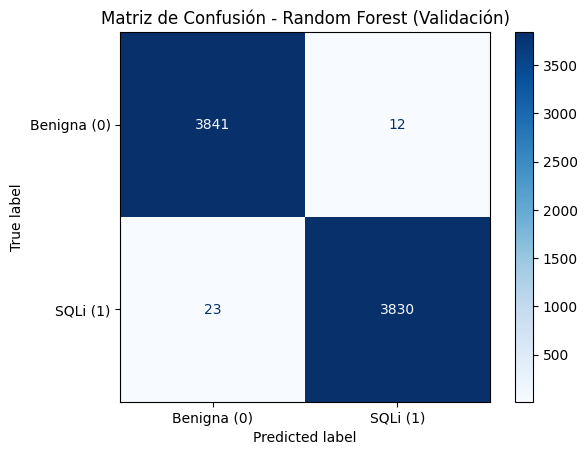

In [41]:
# Matriz de confusión
disp = ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_rf, display_labels=["Benigna (0)", "SQLi (1)"], cmap="Blues"
)
disp.ax_.set_title("Matriz de Confusión - Random Forest (Validación)")
plt.show()

#### Regresión Logística
Evaluación del modelo de Regresión Logística en el conjunto de validación.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Entrenar Regresión Logística
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train, y_train)

# Predicciones en validación
y_val_pred_lr = lr_model.predict(X_val)

In [43]:
report_dict = classification_report(
    y_val, y_val_pred_lr, target_names=["Benigna (0)", "SQLi (1)"], output_dict=True
)
pd.DataFrame(report_dict).T

,precision,recall,f1-score,support
Benigna (0),0.972108,0.985985,0.978998,3853.000000
SQLi (1),0.985782,0.971710,0.978696,3853.000000
accuracy,0.978848,0.978848,0.978848,0.978848
macro avg,0.978945,0.978848,0.978847,7706.000000
weighted avg,0.978945,0.978848,0.978847,7706.000000


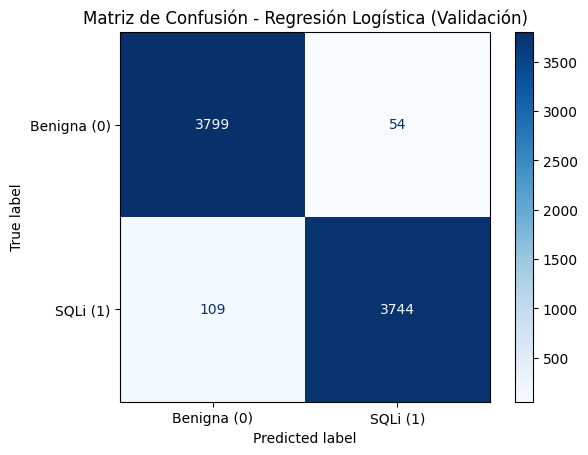

In [44]:
# Matriz de confusión
disp = ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_lr, display_labels=["Benigna (0)", "SQLi (1)"], cmap="Blues"
)
disp.ax_.set_title("Matriz de Confusión - Regresión Logística (Validación)")
plt.show()

#### SVM (Support Vector Machine)
Evaluación del modelo SVM con kernel sigmoid en el conjunto de validación.

In [ ]:
from sklearn.svm import SVC

# Entrenar SVM
svm_model = SVC(kernel='sigmoid', C=1.0, random_state=42, probability=True)  # probability=True para obtener probabilidades
svm_model.fit(X_train, y_train)

# Predicciones en validación
y_val_pred_svm = svm_model.predict(X_val)

In [45]:
report_dict = classification_report(
    y_val, y_val_pred_svm, target_names=["Benigna (0)", "SQLi (1)"], output_dict=True
)
pd.DataFrame(report_dict).T

,precision,recall,f1-score,support
Benigna (0),0.929012,0.937451,0.933213,3853.000000
SQLi (1),0.936878,0.928368,0.932603,3853.000000
accuracy,0.932909,0.932909,0.932909,0.932909
macro avg,0.932945,0.932909,0.932908,7706.000000
weighted avg,0.932945,0.932909,0.932908,7706.000000


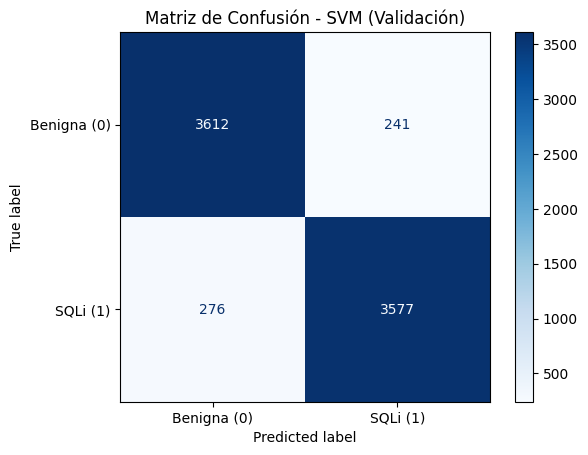

In [46]:
# Matriz de confusión
disp = ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_svm, display_labels=["Benigna (0)", "SQLi (1)"], cmap="Blues"
)
disp.ax_.set_title("Matriz de Confusión - SVM (Validación)")
plt.show()

### Evaluación Final en Conjunto de Test (Datos No Vistos)

Esta es la evaluación definitiva con datos que no fueron utilizados ni durante el entrenamiento ni durante la validación. Estos resultados son los más representativos del rendimiento real del modelo en producción.

Se utilizaron las métricas de precisión, recall y F1-score, especialmente para la clase de inyección SQL (1), que es la clase crítica y la que interesa clasificar correctamente (un falso negativo podría suponer un riesgo para la seguridad del sistema que implemente el modelo como medida de seguridad).

In [47]:
# Evaluación final en conjunto de test
print("EVALUACIÓN FINAL EN CONJUNTO DE TEST")
print("=" * 50)

# Almacenar resultados para comparación
test_results = {}

# Random Forest
y_test_pred_rf = rf_model.predict(X_test)
test_results['Random Forest'] = {
    'predictions': y_test_pred_rf,
    'accuracy': rf_model.score(X_test, y_test),
    'report': classification_report(y_test, y_test_pred_rf, output_dict=True)
}

print("\n1. RANDOM FOREST:")
print(classification_report(y_test, y_test_pred_rf, target_names=['Benigna (0)', 'SQLi (1)']))

# Regresión Logística
y_test_pred_lr = lr_model.predict(X_test)
test_results['Logistic Regression'] = {
    'predictions': y_test_pred_lr,
    'accuracy': lr_model.score(X_test, y_test),
    'report': classification_report(y_test, y_test_pred_lr, output_dict=True)
}

print("\n2. REGRESIÓN LOGÍSTICA:")
print(classification_report(y_test, y_test_pred_lr, target_names=['Benigna (0)', 'SQLi (1)']))

# SVM
y_test_pred_svm = svm_model.predict(X_test)
test_results['SVM'] = {
    'predictions': y_test_pred_svm,
    'accuracy': svm_model.score(X_test, y_test),
    'report': classification_report(y_test, y_test_pred_svm, output_dict=True)
}

print("\n3. SVM:")
print(classification_report(y_test, y_test_pred_svm, target_names=['Benigna (0)', 'SQLi (1)']))

# Resumen de accuracy
print("\nRESUMEN DE ACCURACY EN TEST:")
for model_name, results in test_results.items():
    print(f"{model_name}: {results['accuracy']:.4f}")

EVALUACIÓN FINAL EN CONJUNTO DE TEST

1. RANDOM FOREST:
              precision    recall  f1-score   support

 Benigna (0)       0.99      1.00      0.99      3853
    SQLi (1)       1.00      0.99      0.99      3853

    accuracy                           0.99      7706
   macro avg       0.99      0.99      0.99      7706
weighted avg       0.99      0.99      0.99      7706


2. REGRESIÓN LOGÍSTICA:
              precision    recall  f1-score   support

 Benigna (0)       0.97      0.98      0.98      3853
    SQLi (1)       0.98      0.97      0.98      3853

    accuracy                           0.98      7706
   macro avg       0.98      0.98      0.98      7706
weighted avg       0.98      0.98      0.98      7706


3. SVM:
              precision    recall  f1-score   support

 Benigna (0)       0.93      0.94      0.94      3853
    SQLi (1)       0.94      0.93      0.93      3853

    accuracy                           0.94      7706
   macro avg       0.94      0.94     

### Comparación Exhaustiva de Modelos

Análisis comparativo detallado de todos los modelos evaluados, incluyendo métricas de rendimiento, visualizaciones y recomendaciones para selección del mejor modelo.

Las métricas hacen hincapié en la precisión, recall y F1-score, especialmente para la clase de inyección SQL (1), ya que es la más crítica. En aplicaciones de seguridad:

- **Falsos Negativos (FN)**: Inyecciones SQL no detectadas - **CRÍTICO**
- **Falsos Positivos (FP)**: Consultas benignas marcadas como maliciosas - molesto pero no crítico
- **Verdaderos Positivos (TP)**: Inyecciones SQL correctamente detectadas - **OBJETIVO**
- **Verdaderos Negativos (TN)**: Consultas benignas correctamente clasificadas

**Priorización de métricas**:
1. **Recall (Sensibilidad)**: Capacidad de detectar todas las inyecciones SQL
2. **Precision**: Evitar demasiadas falsas alarmas
3. **F1-Score**: Balance entre precision y recall
4. **Accuracy**: Rendimiento general del modelo

In [ ]:
# Crear tabla comparativa de métricas en conjunto de test
comparison_metrics = pd.DataFrame(
    {
        # COLUMNA 1: Métricas de Random Forest
        "Random Forest": [
            test_results["Random Forest"]["report"][
                "accuracy"
            ],  # Exactitud general del modelo
            test_results["Random Forest"]["report"]["1"][
                "precision"
            ],  # Precisión para clase SQLi (1)
            test_results["Random Forest"]["report"]["1"][
                "recall"
            ],  # Sensibilidad para clase SQLi (1)
            test_results["Random Forest"]["report"]["1"][
                "f1-score"
            ],  # F1-Score para clase SQLi (1)
            test_results["Random Forest"]["report"]["macro avg"][
                "precision"
            ],  # Precisión promedio entre clases
            test_results["Random Forest"]["report"]["macro avg"][
                "recall"
            ],  # Recall promedio entre clases
            test_results["Random Forest"]["report"]["macro avg"][
                "f1-score"
            ],  # F1-Score promedio entre clases
        ],
        # COLUMNA 2: Métricas de Regresión Logística (misma estructura)
        "Logistic Regression": [
            test_results["Logistic Regression"]["report"]["accuracy"],
            test_results["Logistic Regression"]["report"]["1"]["precision"],
            test_results["Logistic Regression"]["report"]["1"]["recall"],
            test_results["Logistic Regression"]["report"]["1"]["f1-score"],
            test_results["Logistic Regression"]["report"]["macro avg"]["precision"],
            test_results["Logistic Regression"]["report"]["macro avg"]["recall"],
            test_results["Logistic Regression"]["report"]["macro avg"]["f1-score"],
        ],
        # COLUMNA 3: Métricas de SVM (misma estructura)
        "SVM": [
            test_results["SVM"]["report"]["accuracy"],
            test_results["SVM"]["report"]["1"]["precision"],
            test_results["SVM"]["report"]["1"]["recall"],
            test_results["SVM"]["report"]["1"]["f1-score"],
            test_results["SVM"]["report"]["macro avg"]["precision"],
            test_results["SVM"]["report"]["macro avg"]["recall"],
            test_results["SVM"]["report"]["macro avg"]["f1-score"],
        ],
    },
    index=[
        "Accuracy",  # Fila 1: Exactitud total
        "Precision (SQLi)",  # Fila 2: Precisión específica para inyecciones SQL
        "Recall (SQLi)",  # Fila 3: Recall específico para inyecciones SQL
        "F1-Score (SQLi)",  # Fila 4: F1-Score específico para inyecciones SQL
        "Precision (Macro)",  # Fila 5: Precisión promedio entre ambas clases
        "Recall (Macro)",  # Fila 6: Recall promedio entre ambas clases
        "F1-Score (Macro)",  # Fila 7: F1-Score promedio entre ambas clases
    ],
)

print("TABLA COMPARATIVA DE MÉTRICAS (CONJUNTO DE TEST)")
comparison_metrics.round(4)

TABLA COMPARATIVA DE MÉTRICAS (CONJUNTO DE TEST)


,Random Forest,Logistic Regression,SVM
Accuracy,0.9948,0.9770,0.9354
Precision (SQLi),0.9979,0.9847,0.9432
Recall (SQLi),0.9917,0.9691,0.9266
F1-Score (SQLi),0.9948,0.9768,0.9348
Precision (Macro),0.9948,0.9772,0.9355
Recall (Macro),0.9948,0.9770,0.9354
F1-Score (Macro),0.9948,0.9770,0.9354


In [49]:
# Encontrar el mejor modelo por métrica
print("MEJOR MODELO POR MÉTRICA:")
for metric in comparison_metrics.index:
    best_model = comparison_metrics.loc[metric].idxmax()
    best_value = comparison_metrics.loc[metric].max()
    print(f"{metric}: {best_model} ({best_value:.4f})")

MEJOR MODELO POR MÉTRICA:
Accuracy: Random Forest (0.9948)
Precision (SQLi): Random Forest (0.9979)
Recall (SQLi): Random Forest (0.9917)
F1-Score (SQLi): Random Forest (0.9948)
Precision (Macro): Random Forest (0.9948)
Recall (Macro): Random Forest (0.9948)
F1-Score (Macro): Random Forest (0.9948)


#### Gráficos de comparación de métricas

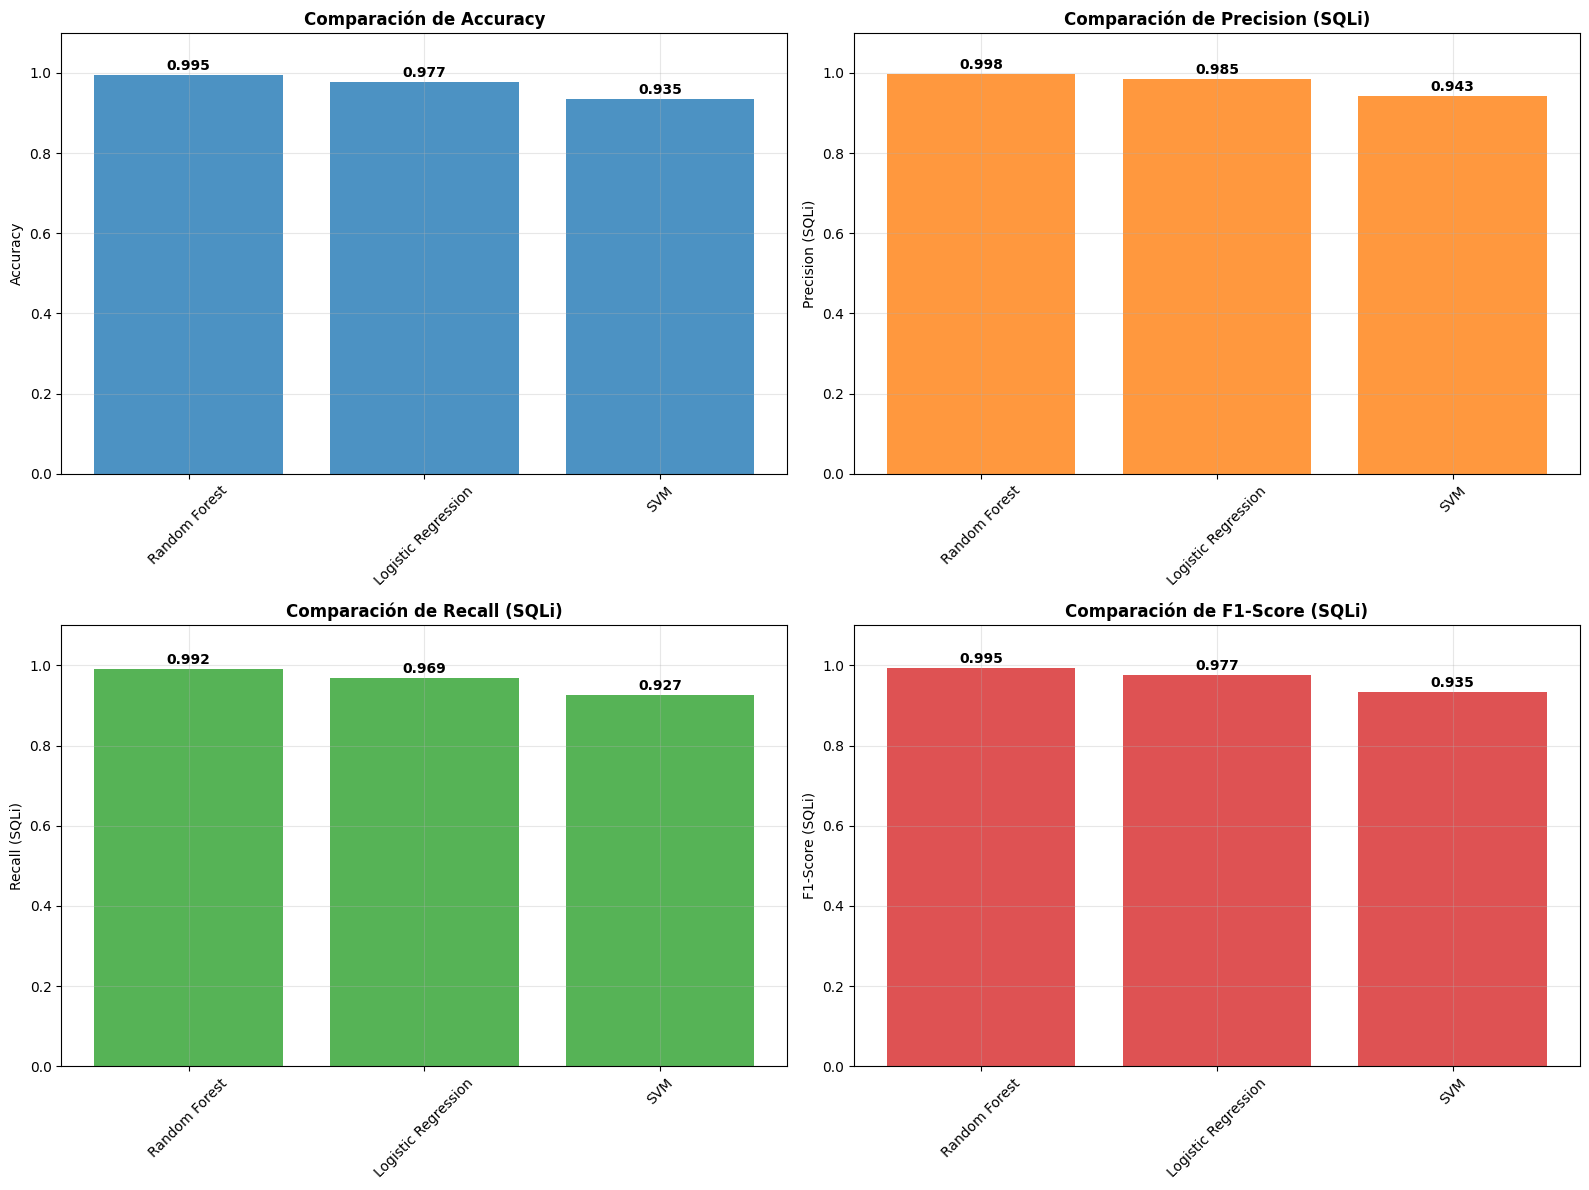

In [54]:
# Visualizaciones comparativas
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Comparación de métricas principales
metrics_to_plot = ['Accuracy', 'Precision (SQLi)', 'Recall (SQLi)', 'F1-Score (SQLi)']
models = comparison_metrics.columns
x_pos = np.arange(len(models))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i//2, i%2]
    values = comparison_metrics.loc[metric].values
    bars = ax.bar(x_pos, values, color=colors[i], alpha=0.8)
    
    # Agregar valores en las barras
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    ax.set_title(f'Comparación de {metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, rotation=45)
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

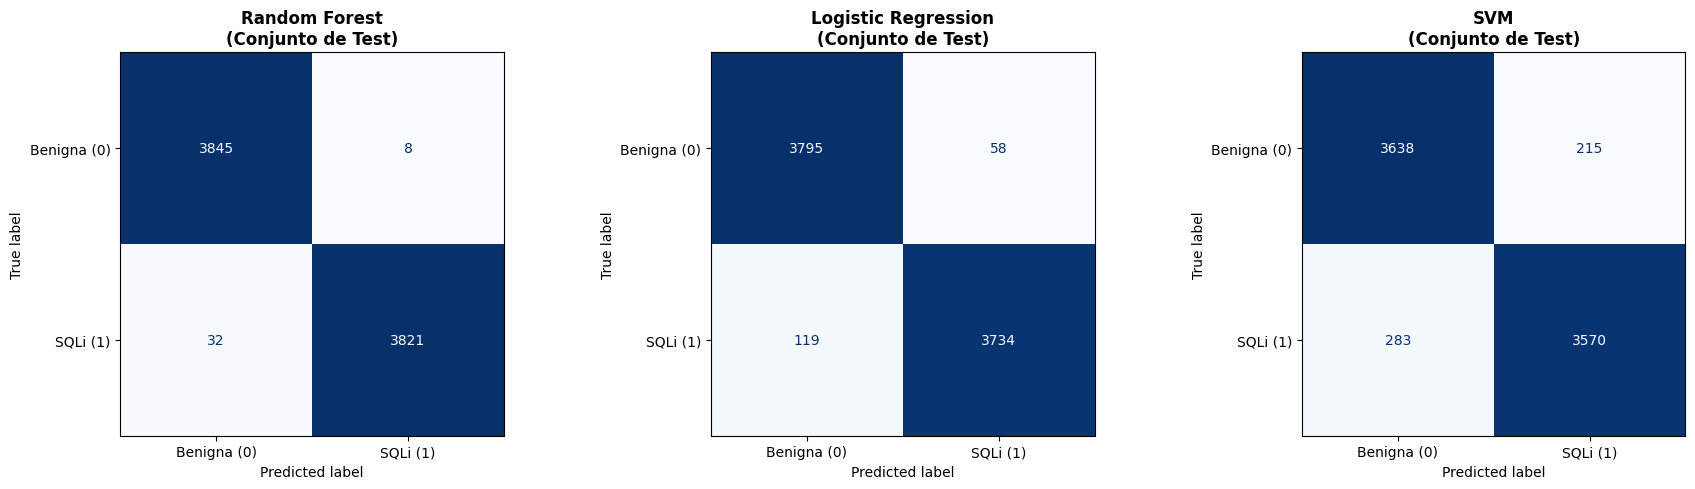

In [50]:
# 2. Matrices de confusión comparativas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_predictions = [
    ('Random Forest', y_test_pred_rf),
    ('Logistic Regression', y_test_pred_lr),
    ('SVM', y_test_pred_svm)
]

for i, (model_name, predictions) in enumerate(models_predictions):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, predictions, 
        display_labels=['Benigna (0)', 'SQLi (1)'],
        ax=axes[i], cmap='Blues', colorbar=False
    )
    axes[i].set_title(f'{model_name}\n(Conjunto de Test)', fontweight='bold')

plt.tight_layout()
plt.show()

## Limitaciones del Estudio
Se debe considerar que la reproducción de los experimentos se vió limitada por la falta recursos computacionales para poder ejecutar los modelos con representaciones de los datos con menor pérdida de información, y mejores parámetros. Sin embargo, esto no se vió reflejado en los resultados finales.

Además, el modelo está entrenado con un dataset específico que puede no representar todos los tipos de inyecciones SQL existentes. Se pueden realizar pruebas exhaustivas con más datasets para validar la capacidad de generalización del modelo.

## Conclusiones
Después de realizar un análisis con validación cruzada, balanceo de clases mediante SMOTE, y evaluación en datos completamente no vistos, se concluyó que la representación de sentencias SQL mediante n-gramas de caracteres con TF-IDF demostró ser efectiva. El balanceo de las clases con SMOTE mejoró significativamente el recall de la clase minoritaria, que era la clase más crítica.

Luego de la ejecución y evaluación de los modelos, Random Forest mostró consistentemente tener el mejor rendimiento en todas las métricas, seguido por la Regresión Logística en segundo lugar y SVM en el tercero, que también tuvieron excelentes métricas, mayores a 0.93 en todas para todos los modelos.

Este trabajo confirma la hipótesis inicial de que es posible detectar ataques de inyección SQL mediante técnicas de Machine Learning con alta precisión (>95% accuracy en conjunto de test), utilizando representaciones TF-IDF de n-gramas de caracteres y algoritmos de clasificación clásicos.

## Referencias
- [Kaggle SQL Injection Dataset](https://www.kaggle.com/datasets/syedsaqlainhussain/sql-injection-dataset)
- [Analyzing comparison performance model of machine learning through detection SQL Injection attack](https://jurnal.stkippgritulungagung.ac.id/index.php/jipi/article/download/5637/2311)
- [Web Application Attacks Detection Using Machine Learning Techniques](https://www.researchgate.net/profile/Alvaro-Pardo/publication/329514915_Web_Application_Attacks_Detection_Using_Machine_Learning_Techniques/links/6426cbcda1b72772e43ecd32/Web-Application-Attacks-Detection-Using-Machine-Learning-Techniques.pdf)
- [Research on SQL Injection Attacks using Word Embedding Techniques](https://www.researchgate.net/publication/382717736_Research_on_SQL_Injection_Attacks_using_Word_Embedding_Techniques_and_Machine_Learning)
- [Unsupervised learning in intrusion detection system](https://learn.saylor.org/mod/book/view.php?chapterid=5435&id=29755)

## Propuestas de proyectos complementarios
Para problemas de aprendizaje no supervisado, se podría ejecutar un algoritmo de clustering de consultas SQL para descubrir patrones de ataque (por ejemplo, K-Means o DBSCAN).
Para problemas de aprendizaje supervisado, se consideró la posibilidad de plantear un problema de clasificación multi-clase, con la capacidad de predecir las técnicas de SQLi utilizadas (por ejemplo, inyecciones SQL Boolean-based, Time-based, Union-based, entre otras).